In [2]:
import numpy as np
import matplotlib.pyplot as plt

SVD offers geometric intuitions to descibes the transformation matrix

# CONSTRUCTION OF SVD without built-in-function

In [3]:
A = np.array([[2,5],
              [3,9],
              [4,1]])
# To obtain U from eigenvector of AAT (column operation)
_, U = np.linalg.eig(A @ A.T)

# To obtain VT from eigenvector of ATA (row operation)
lam, V = np.linalg.eig(A.T @ A)
VT = V.T

# To obtain singular value E -> submatrix (diagonal matrix)
sigma = np.sqrt(lam)
E = sigma

# diagonal matrix
diag = np.diag(E)
np.round(diag)

array([[ 3.,  0.],
       [ 0., 11.]])

# CONSTRUCTION OF SVD using built-in-function

In [4]:
A = np.array([[2,3],
              [5,3],
              [4,1]])

U, E, VT = np.linalg.svd(A)

# U: u1, u2 are left singular vectors
u1 = U[:, 0]
u2 = U[:, 1]

# V: v1, v2 are right singular vectors
v1 = VT[0,: ]
v2 = VT[1, : ]

# singular value
sigma_max = np.max(E)
sigma_min = np.min(E)

# condition number
cn = sigma_max/sigma_min

# Outputs
# print(f"u1 =\n {np.column_stack([u1])}")
# print(f"\nu2 =\n {np.column_stack([u2])}")

# print(f"\nv1 =\n {np.column_stack([v1])}")
# print(f"v2 =\n {np.column_stack([v2])}")

# print(f"\nCondition number = {round(cn)}")

# Verification of A = U E VT
# Avi = sigma_ui, for each i AV = U E,  VT = V^-1 , A = U E VT

Av1 = A @ v1
Av2 = A @ v2
sigma = E
sigma_u1 = sigma[0] * u1
sigma_u2 = sigma[1] * u2

print("Verification of A = U E VT ")
print(f"Av1 = sigma_u1 -> {(np.allclose(Av1, sigma_u1))}")
print(f"Av2 = sigma_u2 -> {(np.allclose(Av2, sigma_u2))}")

print(f"Dimension of domain (U) = {U.shape}")
print(f"Dimension of codomain (VT) = {VT.shape}")


Verification of A = U E VT 
Av1 = sigma_u1 -> True
Av2 = sigma_u2 -> True
Dimension of domain (U) = (3, 3)
Dimension of codomain (VT) = (2, 2)


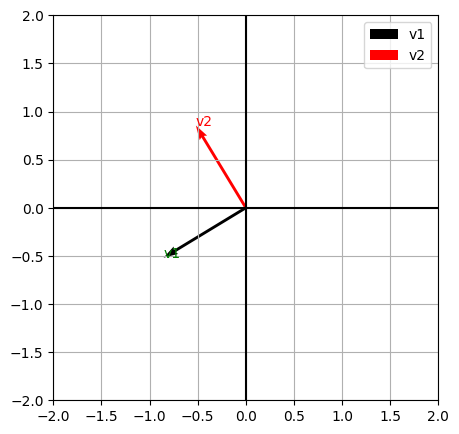

In [5]:
# origin
origin = np.eye(2)[:0]

fig, ax = plt.subplots(figsize=(5,5))

# plot
ax.quiver(*origin, *v1, angles='xy', scale_units='xy', scale=1, color='k', label='v1')
ax.quiver(*origin, *v2, angles='xy', scale_units='xy', scale=1, color='r', label='v2')

# axes 
ax.axhline(0, color='k')
ax.axvline(0, color='k')

# figure style
ax.grid()
ax.set_xlim(-2,2)
ax.set_ylim(-2,2)
ax.set_aspect('equal')
ax.legend()

# arrow representation
ax.text(*v1, s='v1', color='g')
ax.text(*v2, s='v2', color='r')


plt.show()

In [13]:
A = np.array([
    [7,2,4],
    [9,10,6],
    [5,3,9],
    [1,4,7]
])

# Matrix factorization into A = U E VT
U,E,VT  = np.linalg.svd(A)

print(f"U =\n {U}")
print(f"\n E =\n {np.diag(E)}")
print(f"\nVT =\n {VT}")
print()
print(A @ A.T)
print()
print(A.T @ A)

U =
 [[-0.37514195  0.20009821 -0.72133672  0.54671982]
 [-0.70106076  0.56893121  0.39655057 -0.16606848]
 [-0.49725249 -0.5491825  -0.33498293 -0.58217264]
 [-0.3471632  -0.57851238  0.45848383  0.57844076]]

 E =
 [[20.26862524  0.          0.        ]
 [ 0.          6.13010609  0.        ]
 [ 0.          0.          4.31330848]]

VT =
 [[-0.58064945 -0.52501349 -0.62225963]
 [ 0.52146625  0.34712474 -0.77947249]
 [-0.62523529  0.77708767 -0.07221903]]

[[ 69 107  77  43]
 [107 217 129  91]
 [ 77 129 115  80]
 [ 43  91  80  66]]

[[156 123 134]
 [123 129 123]
 [134 123 182]]
